In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)




c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

In [2]:

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": 10, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}


In [3]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [4]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """
sales = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\train.csv')
stores = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\store.csv')

stores_to_use = [1, 2, 3, 4, 5, 6]
stores = stores[stores['Store'].isin(stores_to_use)]

stores['CompetitionStartDate'] = pd.to_datetime({
    'year': stores['CompetitionOpenSinceYear'],
    'month': stores['CompetitionOpenSinceMonth'],
    'day': 1
    }, errors='coerce')
stores.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'], inplace=True)

df = sales.merge(stores, on='Store', how='inner')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Store', 'Date']) # Sort by Store and Date to ensure chronological order for feature engineering 

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)

In [5]:
import xgboost as xgb
import pandas as pd
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial
from src.engine.target_transformer import TargetTransformer

FORECAST_HORIZON = 10
lags = [pd.DateOffset(days=i) for i in range(FORECAST_HORIZON * 3)] # lag 0 is the current value, lag 1 is the previous day, etc.
diffs = [pd.DateOffset(days=i) for i in [3, 5, 7, 14, 30]]
windows = ['7D', '14D', '30D', '60D']
horizon = pd.DateOffset(days=FORECAST_HORIZON) # We use this to shift the features by the forecast
                                                   # horizon to align them with the target variable.

df_ = df.copy()

# Apply log1p transformation to the Sales column to stabilize variance and make the distribution more normal.
df_['Sales'] = df_['Sales'].apply(np.log1p)

# Interpolate sales for closed days to create anchors for inverting the differencing and log transformation on the predictions,
# so that we can get them back on the original scale for evaluation and plotting.
is_closed = df_['Date'].dt.day_name() == 'Sunday'
df_.loc[is_closed, 'Sales'] = np.nan
df_ = (df_
       .set_index(['Date', 'Store'])
       .sort_index()
       .groupby(level='Store', group_keys=False)
       .apply(lambda x: x.interpolate(method='linear'))
       .reset_index())

X = df_.set_index(['Date']).groupby('Store').apply(lambda df: features.compute(df, lags, diffs, windows, horizon))
trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-FORECAST_HORIZON), anchor_col='lag_days_0')
trf.fit(X)  # Fit the transformer to capture anchors from X so that we can inverse the differencing later when we get the predictions
y = trf.transform(df_.set_index(['Store', 'Date'])['Sales'])  # Transform the target variable to compute the forward difference
X = X.loc[y.index]  # Align features with the target variable by dropping any rows in X that don't have a corresponding target value in y.

inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)


# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.5,        # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'colsample_bytree': 1.0, # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}


mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)


[0]	train-rmse:2.06170+0.08217	test-rmse:1.70738+1.19663
[100]	train-rmse:1.87336+0.07431	test-rmse:1.56411+1.09605
[200]	train-rmse:1.70293+0.06699	test-rmse:1.43657+1.00282
[300]	train-rmse:1.54909+0.06024	test-rmse:1.32207+0.91720
[400]	train-rmse:1.41016+0.05412	test-rmse:1.22051+0.83848
[500]	train-rmse:1.28472+0.04870	test-rmse:1.13114+0.76779
[600]	train-rmse:1.17162+0.04367	test-rmse:1.05318+0.70580
[700]	train-rmse:1.06937+0.03931	test-rmse:0.98415+0.64895
[800]	train-rmse:0.97735+0.03524	test-rmse:0.92453+0.59826
[900]	train-rmse:0.89426+0.03152	test-rmse:0.86987+0.55489
[1000]	train-rmse:0.81926+0.02829	test-rmse:0.82122+0.51420
[1100]	train-rmse:0.75183+0.02539	test-rmse:0.77911+0.47916
[1200]	train-rmse:0.69113+0.02249	test-rmse:0.74171+0.44889
[1300]	train-rmse:0.63653+0.02005	test-rmse:0.71044+0.42164
[1400]	train-rmse:0.58753+0.01772	test-rmse:0.68297+0.39978
[1500]	train-rmse:0.54341+0.01566	test-rmse:0.65909+0.37984
[1600]	train-rmse:0.50393+0.01378	test-rmse:0.63950+

np.float64(0.5380366908500896)

In [10]:
booster = hypertuning.refit(X, y, mock_trial, study_config)
test_dmatrix = xgb.DMatrix(X, enable_categorical=True)

In [11]:

preds_log_diff = pd.Series(data=booster.predict(test_dmatrix),
                           index=X.index)
preds = trf.inverse_transform(preds_log_diff)  # Inverse transform to get predictions back on the original scale

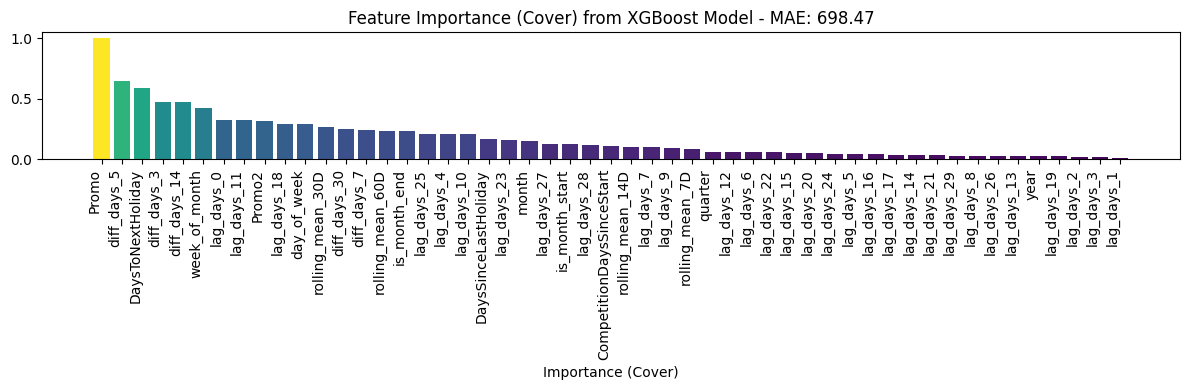

In [12]:
# Extract feature importance from the booster and plot it
importance = booster.get_score(importance_type='cover')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

importance_df['importance'] = importance_df['importance'] / importance_df['importance'].max()  # Normalize to sum to 1

results = pd.DataFrame({
    'actuals': df.set_index(['Store', 'Date'])['Sales'],  # Inverse of log1p applied to the targets during training
    'predictions': preds
}).dropna().sort_index()

from sklearn.metrics import  mean_absolute_error
mae = mean_absolute_error(results["actuals"], results["predictions"])

plt.figure(figsize=(12, 4))
plt.bar(importance_df['feature'], importance_df['importance'], color=cm.viridis(importance_df['importance']))
plt.xlabel('Importance (Cover)')
plt.title('Feature Importance (Cover) from XGBoost Model - MAE: {:.2f}'.format(mae))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
plt.tight_layout()

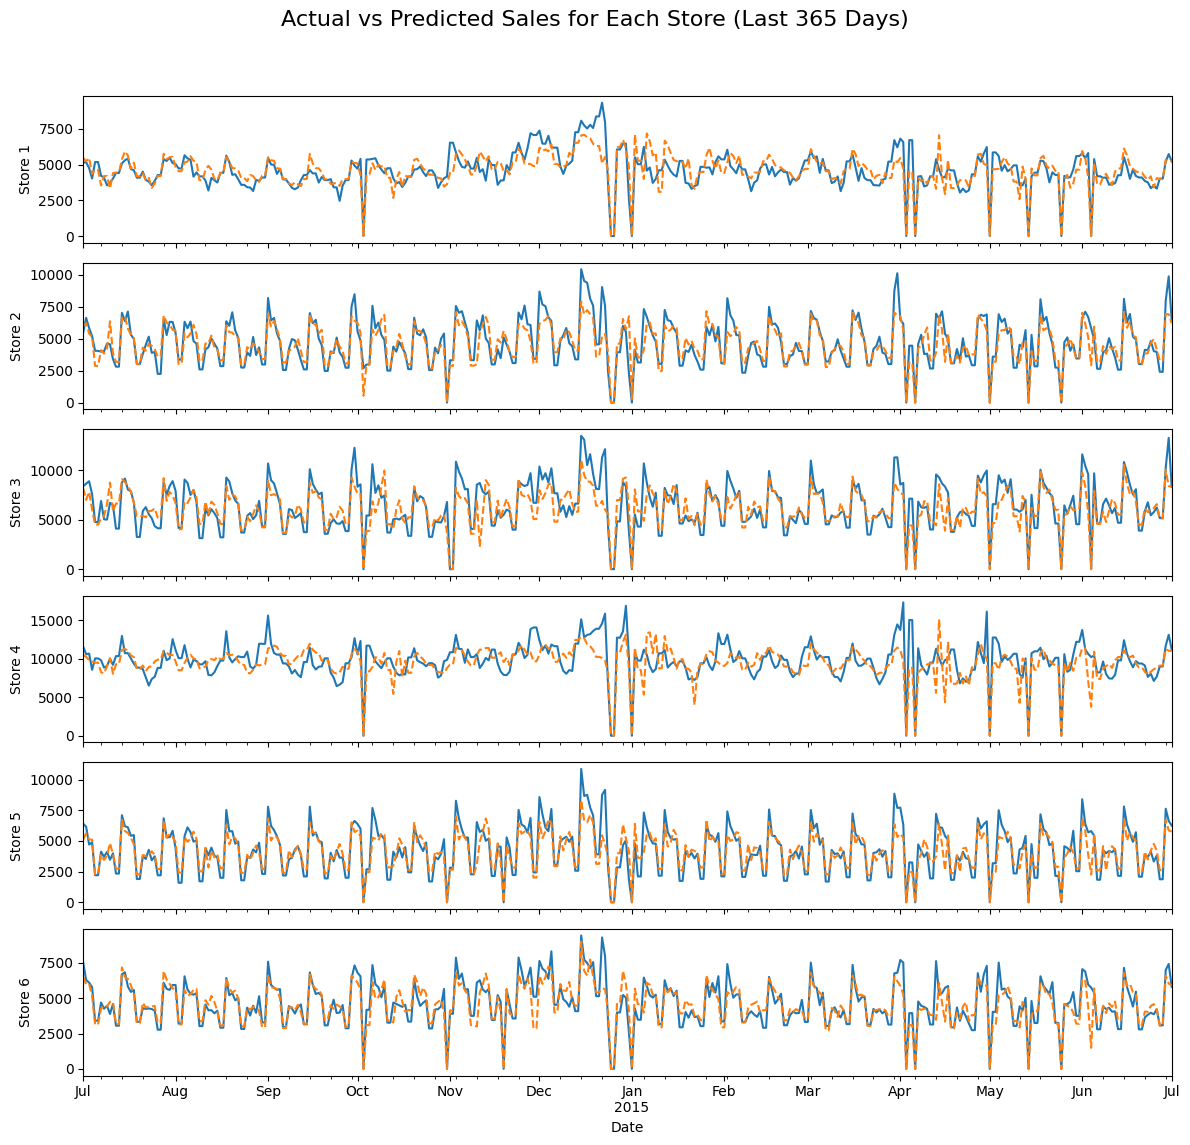

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n_days_to_plot = 365
n_days_offset  = 1*30  # Offset to start plotting from 3 months ago

max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'actuals']
preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'predictions']

stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(stores)), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

    # 
    
    closed_days = actual_store_sales.index.get_level_values("Date").day_name() == 'Sunday'
    closed_days = actual_store_sales[closed_days].index.get_level_values("Date")
    actual_store_sales[closed_days]    = np.nan  # Set closed days to NaN for plotting
    predicted_store_sales[closed_days] = np.nan  # Set closed days to NaN for plotting
    actual_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot


    actual_store_sales.plot(label=f"Actual", ax=ax[i])
    predicted_store_sales.plot(label=f"Predicted", ax=ax[i], linestyle='--')

    
    #ax[i].legend()
    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")
plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle